In [2]:
#Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

In [3]:
#Loading the dataset
df = pd.read_csv("districtwise-crime-against-children-2017-onwards.csv")
df

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder_with_rape,other_murder,abetment_suicide_of_child,...,other_offences_juveniles,procur_induc_children_sake_prost,detain_prsn_whr_prost_carried,other_immoral_traffic,child_labour,prohib_child_marriage,transplantn_human_organs,pub_trns_mat_depict_child_sexul_explicit,other_cyber_crimes_agnst_children,other_sll_crimes
0,0,2022,Andhra Pradesh,28,Alluri Sitharama Raju,745,Alluri Sitharama Raju,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,2022,Andhra Pradesh,28,Anakapalli,744,Anakapalli,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2022,Andhra Pradesh,28,Anantapur,502,Anantapuramu,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,0.0
3,3,2022,Andhra Pradesh,28,Annamayya,753,Annamayya,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,2022,Andhra Pradesh,28,Bapatla,750,Bapatla,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5316,5316,2021,Ladakh,37,Kargil,6,Kargil,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5317,5317,2021,Ladakh,37,Leh Ladakh,9,Leh,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5318,5318,2021,Lakshadweep,31,Lakshadweep District,553,Lakshadweep,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5319,5319,2021,Puducherry,34,Karaikal,598,Karaikal,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
## Exploratory Data Analysis (EDA)
df.head(5)

,id,year,state_name,state_code,district_name,district_code,registration_circles,murder_with_rape,other_murder,abetment_suicide_of_child,...,other_offences_juveniles,procur_induc_children_sake_prost,detain_prsn_whr_prost_carried,other_immoral_traffic,child_labour,prohib_child_marriage,transplantn_human_organs,pub_trns_mat_depict_child_sexul_explicit,other_cyber_crimes_agnst_children,other_sll_crimes
0,0,2022,Andhra Pradesh,28,Alluri Sitharama Raju,745,Alluri Sitharama Raju,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,2022,Andhra Pradesh,28,Anakapalli,744,Anakapalli,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2022,Andhra Pradesh,28,Anantapur,502,Anantapuramu,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,0.0
3,3,2022,Andhra Pradesh,28,Annamayya,753,Annamayya,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,2022,Andhra Pradesh,28,Bapatla,750,Bapatla,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5321 entries, 0 to 5320
Data columns (total 58 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   id                                        5321 non-null   int64  
 1   year                                      5321 non-null   int64  
 2   state_name                                5321 non-null   object 
 3   state_code                                5321 non-null   int64  
 4   district_name                             5321 non-null   object 
 5   district_code                             5321 non-null   int64  
 6   registration_circles                      5321 non-null   object 
 7   murder_with_rape                          5321 non-null   float64
 8   other_murder                              5321 non-null   float64
 9   abetment_suicide_of_child                 5321 non-null   float64
 10  attempt_to_commit_murder            

In [6]:
df.describe()

,id,year,state_code,district_code,murder_with_rape,other_murder,abetment_suicide_of_child,attempt_to_commit_murder,infanticide,foeticide,...,other_offences_juveniles,procur_induc_children_sake_prost,detain_prsn_whr_prost_carried,other_immoral_traffic,child_labour,prohib_child_marriage,transplantn_human_organs,pub_trns_mat_depict_child_sexul_explicit,other_cyber_crimes_agnst_children,other_sll_crimes
count,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,...,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.000000,5321.0,5321.000000,5321.000000,5321.000000
mean,2660.000000,2019.554971,17.612667,371.344108,0.142079,1.397482,0.312723,0.365345,0.083255,0.133809,...,1.818831,0.022176,0.001128,0.012780,0.664537,0.800226,0.0,0.569066,0.114828,0.154106
std,1536.184722,1.709778,9.892892,429.148605,0.497095,2.310743,0.939288,2.409402,0.562306,0.726088,...,8.185414,0.253318,0.051287,0.160551,5.590980,2.402874,0.0,3.699443,1.080660,2.240671
min,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,1330.000000,2018.000000,9.000000,172.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,2660.000000,2020.000000,18.000000,357.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
75%,3990.000000,2021.000000,24.000000,538.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
max,5320.000000,2022.000000,38.000000,9999.000000,11.000000,29.000000,17.000000,112.000000,23.000000,16.000000,...,250.000000,7.000000,3.000000,5.000000,289.000000,40.000000,0.0,134.000000,30.000000,115.000000


In [7]:
df.isnull().sum()

id                                          0
year                                        0
state_name                                  0
state_code                                  0
district_name                               0
district_code                               0
registration_circles                        0
murder_with_rape                            0
other_murder                                0
abetment_suicide_of_child                   0
attempt_to_commit_murder                    0
infanticide                                 0
foeticide                                   0
exposure_and_abandonment                    0
simple_hurt                                 0
grievous_hurt                               0
missing_child_kidnapped                     0
other_kidnp_abductn_sec_363                 0
kidnp_abductn_purpose_begging               0
kidnp_abductn_order_to_murder               0
kidnp_for_ransom                            0
kidnp_abductn_minor_girls         

In [8]:
# Data Cleaning
df.fillna(0, inplace=True)
df.drop(columns=["id"], inplace=True, errors='ignore')
df

,year,state_name,state_code,district_name,district_code,registration_circles,murder_with_rape,other_murder,abetment_suicide_of_child,attempt_to_commit_murder,...,other_offences_juveniles,procur_induc_children_sake_prost,detain_prsn_whr_prost_carried,other_immoral_traffic,child_labour,prohib_child_marriage,transplantn_human_organs,pub_trns_mat_depict_child_sexul_explicit,other_cyber_crimes_agnst_children,other_sll_crimes
0,2022,Andhra Pradesh,28,Alluri Sitharama Raju,745,Alluri Sitharama Raju,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2022,Andhra Pradesh,28,Anakapalli,744,Anakapalli,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022,Andhra Pradesh,28,Anantapur,502,Anantapuramu,0.0,4.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,0.0
3,2022,Andhra Pradesh,28,Annamayya,753,Annamayya,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2022,Andhra Pradesh,28,Bapatla,750,Bapatla,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5316,2021,Ladakh,37,Kargil,6,Kargil,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5317,2021,Ladakh,37,Leh Ladakh,9,Leh,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5318,2021,Lakshadweep,31,Lakshadweep District,553,Lakshadweep,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5319,2021,Puducherry,34,Karaikal,598,Karaikal,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
#Handling missing values
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(0)

cat_cols = df.select_dtypes(include=['object', 'string']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.dropna(subset=["state_name", "district_name"], inplace=True)

df

,year,state_name,state_code,district_name,district_code,registration_circles,murder_with_rape,other_murder,abetment_suicide_of_child,attempt_to_commit_murder,...,other_offences_juveniles,procur_induc_children_sake_prost,detain_prsn_whr_prost_carried,other_immoral_traffic,child_labour,prohib_child_marriage,transplantn_human_organs,pub_trns_mat_depict_child_sexul_explicit,other_cyber_crimes_agnst_children,other_sll_crimes
0,2022,Andhra Pradesh,28,Alluri Sitharama Raju,745,Alluri Sitharama Raju,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2022,Andhra Pradesh,28,Anakapalli,744,Anakapalli,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022,Andhra Pradesh,28,Anantapur,502,Anantapuramu,0.0,4.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,0.0
3,2022,Andhra Pradesh,28,Annamayya,753,Annamayya,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2022,Andhra Pradesh,28,Bapatla,750,Bapatla,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5316,2021,Ladakh,37,Kargil,6,Kargil,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5317,2021,Ladakh,37,Leh Ladakh,9,Leh,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5318,2021,Lakshadweep,31,Lakshadweep District,553,Lakshadweep,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5319,2021,Puducherry,34,Karaikal,598,Karaikal,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


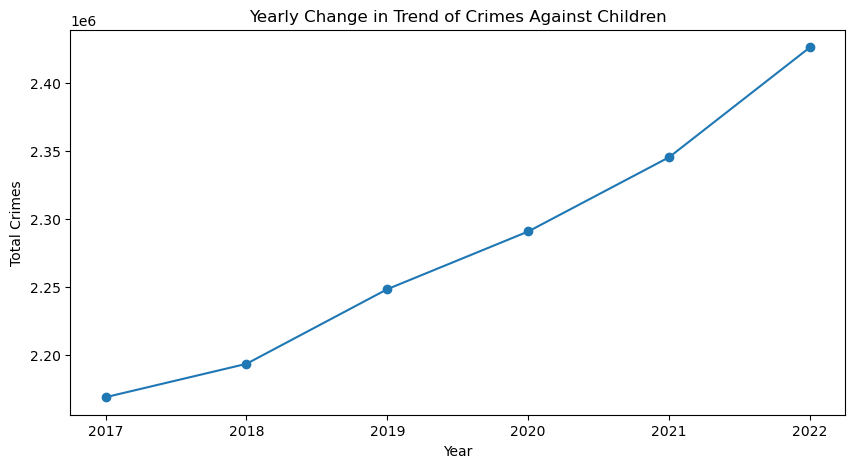

In [10]:
# Change in crime trends over the years
df["total_crime"] = df.select_dtypes(include='number').sum(axis=1)
yearly_crime = df.groupby("year")["total_crime"].sum()

plt.figure(figsize=(10,5))
yearly_crime.plot(marker='o')
plt.title("Yearly Change in Trend of Crimes Against Children")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.show()

/var/folders/qs/g4tzhsk93672gfd2h_zrt7540000gn/T/ipykernel_990/4139910781.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot( x='state_name', y='total_crime', data=df_top, estimator=np.sum,ci=None, palette='viridis', order=top_states)
/var/folders/qs/g4tzhsk93672gfd2h_zrt7540000gn/T/ipykernel_990/4139910781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x='state_name', y='total_crime', data=df_top, estimator=np.sum,ci=None, palette='viridis', order=top_states)


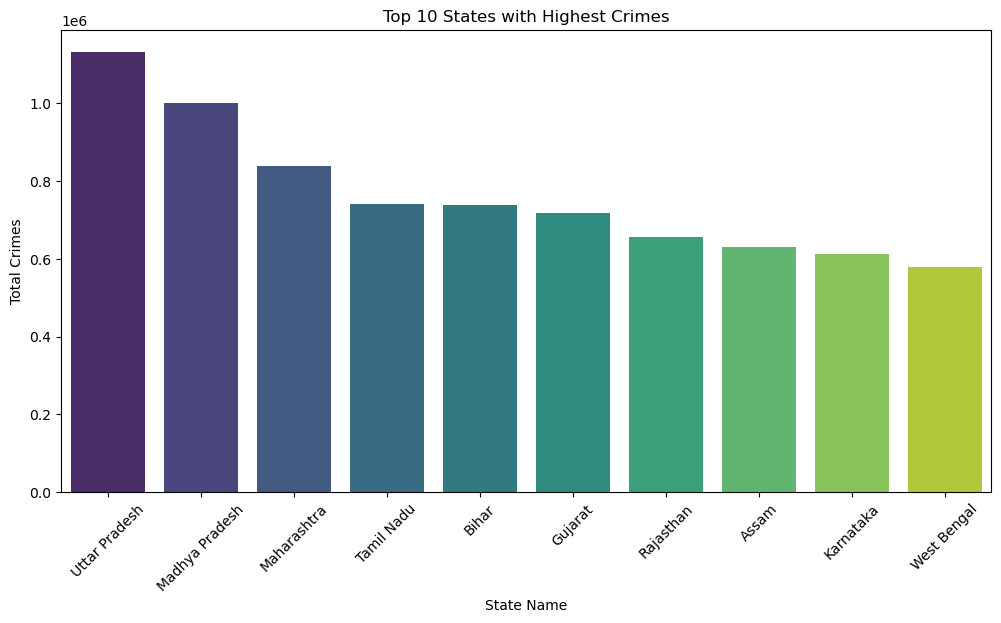

In [11]:
#Top states with crime
top_states = df.groupby("state_name")["total_crime"].sum().nlargest(10).index
df_top = df[df["state_name"].isin(top_states)]

plt.figure(figsize=(12,6))
sns.barplot( x='state_name', y='total_crime', data=df_top, estimator=np.sum,ci=None, palette='viridis', order=top_states)

plt.xticks(rotation=45)
plt.title("Top 10 States with Highest Crimes")
plt.xlabel("State Name")
plt.ylabel("Total Crimes")

plt.show()

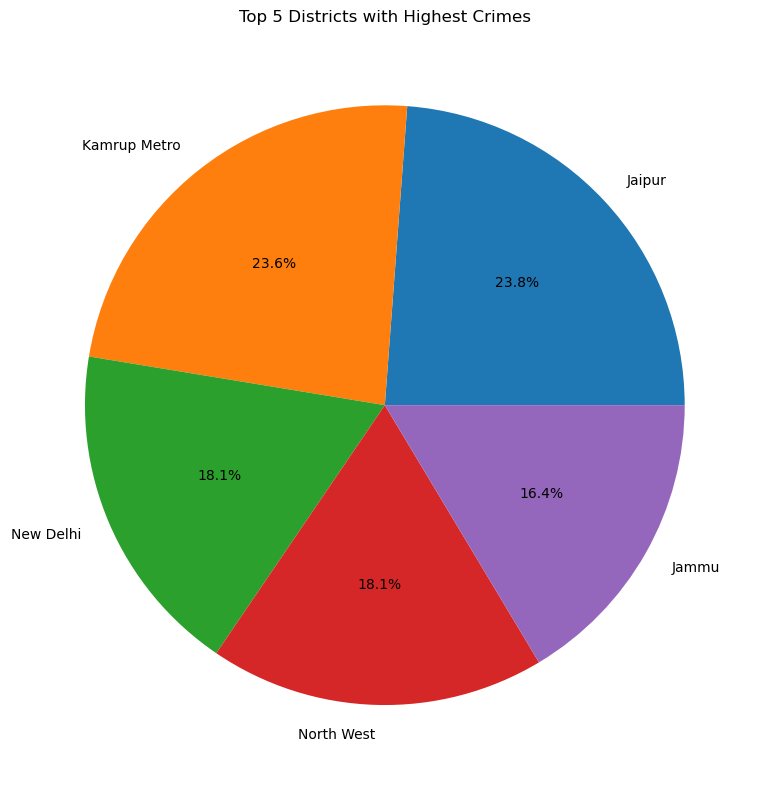

In [12]:
#Year-wise rime distribution
plt.figure(figsize=(8,8))
top_districts = df.groupby("district_name")["total_crime"].sum().sort_values(ascending=False).head(5)

plt.pie( top_districts.values, labels=top_districts.index, autopct='%1.1f%%')

plt.title("Top 5 Districts with Highest Crimes")
plt.tight_layout()
plt.show()

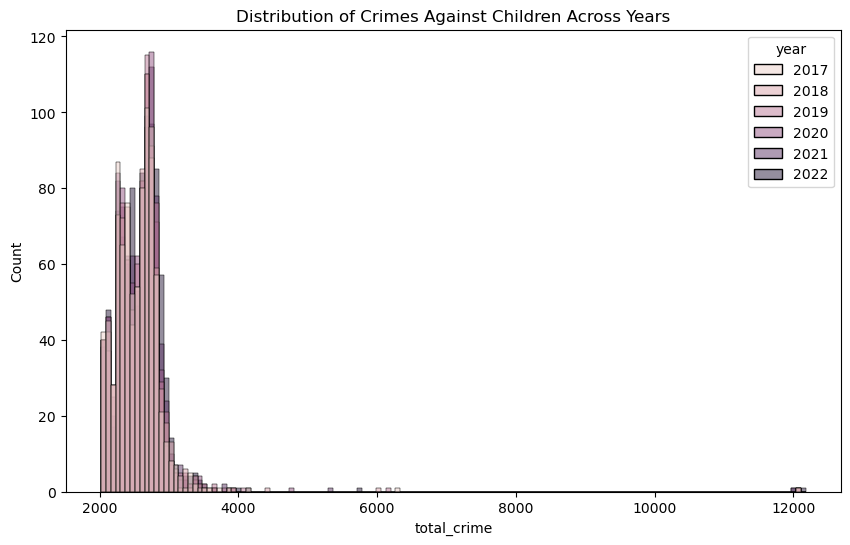

In [13]:
#Histogram
plt.figure(figsize=(10,6))

sns.histplot(data=df, x="total_crime", hue="year")

plt.title("Distribution of Crimes Against Children Across Years")
plt.show()

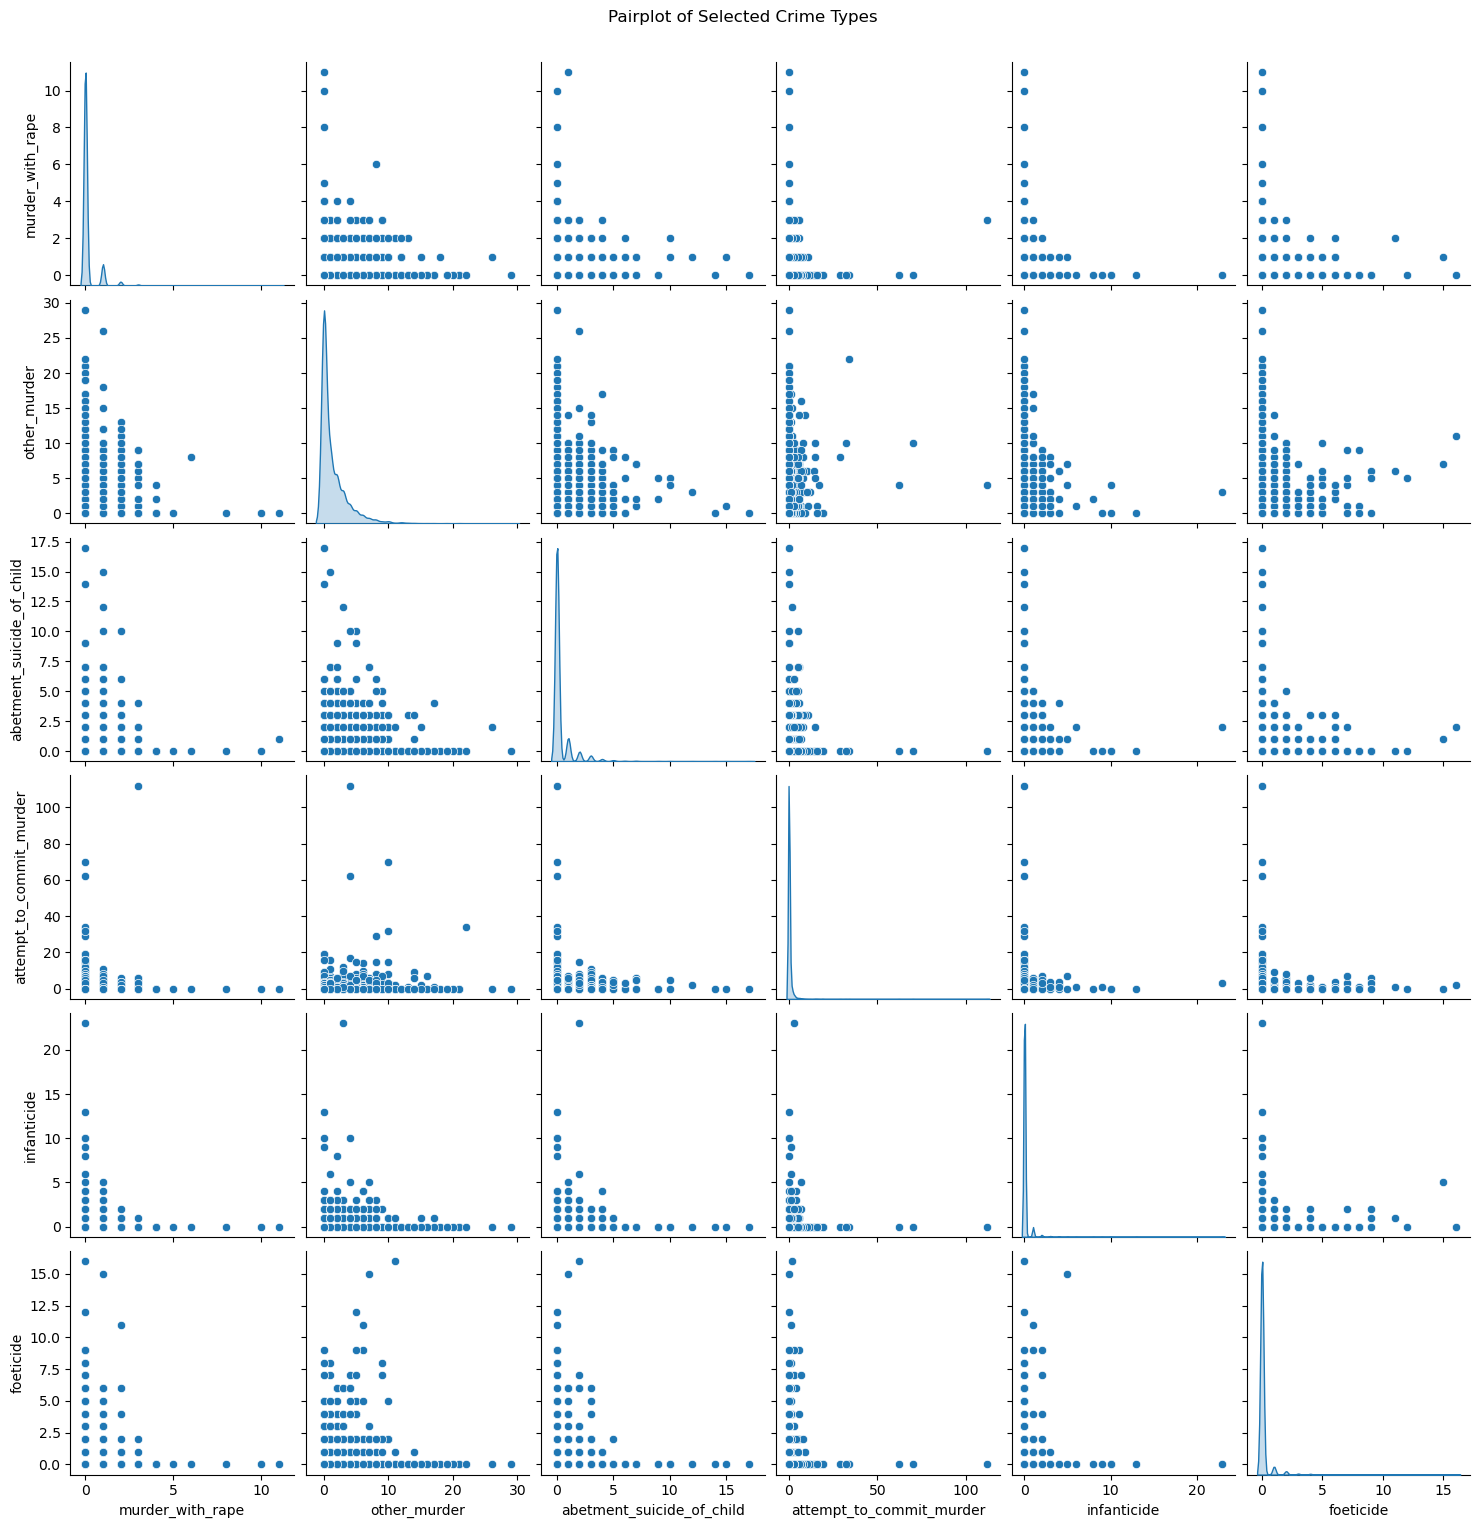

In [14]:
#Pairplot of top-categories of crimes
cols = [
    "murder_with_rape",
    "other_murder",
    "abetment_suicide_of_child",
    "attempt_to_commit_murder",
    "infanticide",
    "foeticide"
]

sns.pairplot(df[cols], diag_kind='kde')

plt.suptitle("Pairplot of Selected Crime Types", y=1.02)
plt.show()

/var/folders/qs/g4tzhsk93672gfd2h_zrt7540000gn/T/ipykernel_990/3857049279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='year', y='total_crime', data=df, palette='viridis')


<Axes: title={'center': 'Boxplot for outlier detection'}, xlabel='year', ylabel='total_crime'>

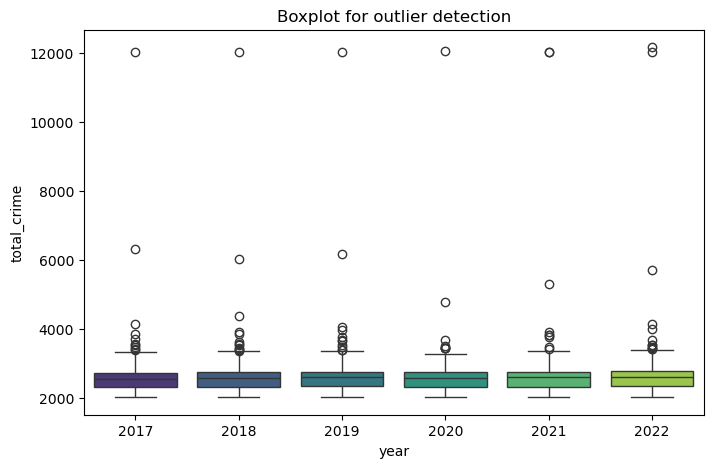

In [15]:
#Boxplot for outlier detection
plt.figure(figsize=(8,5))
plt.title("Boxplot for outlier detection") 
sns.boxplot(x='year', y='total_crime', data=df, palette='viridis')


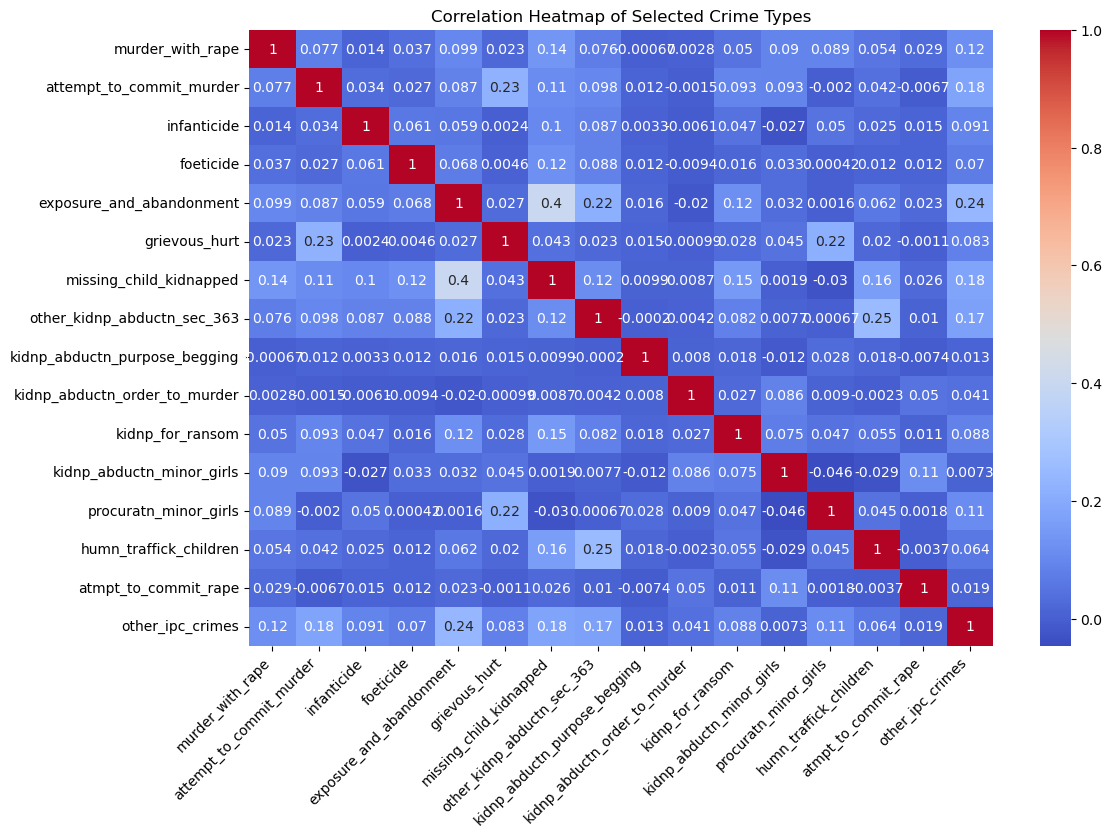

In [16]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

cols = [
    "murder_with_rape","attempt_to_commit_murder", "infanticide", "foeticide",
    "exposure_and_abandonment", "grievous_hurt",
    "missing_child_kidnapped", "other_kidnp_abductn_sec_363",
    "kidnp_abductn_purpose_begging", "kidnp_abductn_order_to_murder",
    "kidnp_for_ransom", "kidnp_abductn_minor_girls",
    "procuratn_minor_girls","humn_traffick_children", "atmpt_to_commit_rape",
    "other_ipc_crimes",
]

corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)

plt.title("Correlation Heatmap of Selected Crime Types")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

In [17]:
#Data preparation
numeric_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df["total_crime"] = df.select_dtypes(include='number').sum(axis=1)

X = df.drop(columns=["total_crime"])
y = df["total_crime"]

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [18]:
# Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
#Model selection
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [20]:
# Model Evaluation
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 67.47929577464787
MSE: 15135.068044600937
R2 Score: 0.9830347758590953
